# DoubleML Tutorial 11: Sample Splitting, Cross-Fitting, And Repeated Cross-Fitting

This notebook is about the machinery that makes double machine learning more than “fit a flexible model and regress residuals.” The key idea is **cross-fitting**: nuisance models are trained on one part of the data and used to predict nuisance quantities on held-out rows. Those held-out nuisance predictions are then used inside an orthogonal score for the treatment effect.

Why does this matter?

Flexible learners can overfit. If a nuisance model predicts the same rows it was trained on, the residuals can become artificially small or distorted. In ordinary prediction work, that is a validation problem. In causal estimation, it is worse: distorted residuals can distort the orthogonal score itself.

A PLR score can be written informally as residualizing both outcome and treatment:

$$
\tilde{Y}_i = Y_i - \hat{\ell}(X_i), \quad \tilde{D}_i = D_i - \hat{m}(X_i),
$$

and then estimating the treatment effect from the relationship between \(\tilde{Y}_i\) and \(\tilde{D}_i\). Cross-fitting asks for \(\hat{\ell}(X_i)\) and \(\hat{m}(X_i)\) to be predictions from models that did not train on row \(i\).

This notebook covers five practical topics:

1. What K-fold cross-fitting is doing.
2. How fold count changes training/validation trade-offs.
3. How repeated cross-fitting reduces dependence on one random split.
4. How to set external splits for grouped data.
5. Why in-sample nuisance residualization can fail with very flexible learners.

Expected runtime: about 30-60 seconds on a laptop. The notebook fits several DoubleML models and a few manual cross-fitting models, but all learners are configured to stay tutorial-friendly.

## Setup

The setup cell follows the same pattern as the earlier DoubleML tutorials. It creates output folders, sets a local Matplotlib cache, imports DoubleML and sklearn tools, and fixes global plotting defaults.

In [1]:
from pathlib import Path
import os
import time
import warnings

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "doubleml":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

import doubleml as dml
from doubleml import DoubleMLData, DoubleMLPLR

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold

NOTEBOOK_PREFIX = "11"
RANDOM_SEED = 42
TRUE_THETA = 1.00

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})

print(f"DoubleML version: {dml.__version__}")
print(f"Output directory: {OUTPUT_DIR}")

DoubleML version: 0.11.2
Output directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/doubleml/outputs


The setup output confirms the package version and the artifact location. The notebook uses only local synthetic data, so every result should be reproducible from the cells below.

## Helper Functions

These helpers handle repeated notebook chores: saving tables, building `DoubleMLData`, computing nuisance metrics, creating sample splits, and fitting a PLR model with a specified split design.

The most important helper is `fit_plr_with_splits()`. It lets us compare DoubleML models while controlling whether the sample splitting is drawn internally or provided externally.

In [2]:
def save_table(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    return path


def save_dataset(df, filename):
    path = DATASET_DIR / filename
    df.to_csv(path, index=False)
    return path


def rmse_metric(y_true, y_pred):
    mask = ~np.isnan(y_true)
    return mean_squared_error(y_true[mask], y_pred[mask]) ** 0.5


def mae_metric(y_true, y_pred):
    mask = ~np.isnan(y_true)
    return mean_absolute_error(y_true[mask], y_pred[mask])


def model_x_cols(df):
    excluded = {"unit_id", "user_id", "outcome", "treatment", "true_g", "true_m", "user_effect"}
    return [col for col in df.columns if col not in excluded]


def make_plr_data(df):
    return DoubleMLData(df, y_col="outcome", d_cols="treatment", x_cols=model_x_cols(df))


def make_kfold_splits(df, n_folds, seed):
    splitter = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    return list(splitter.split(df))


def make_repeated_kfold_splits(df, n_folds, n_rep, seed):
    return [make_kfold_splits(df, n_folds=n_folds, seed=seed + rep) for rep in range(n_rep)]


def fit_plr_with_splits(df, learner, label, n_folds=5, n_rep=1, all_smpls=None, seed=RANDOM_SEED):
    dml_data = make_plr_data(df)
    plr = DoubleMLPLR(
        dml_data,
        ml_l=clone(learner),
        ml_m=clone(learner),
        n_folds=n_folds,
        n_rep=n_rep,
        draw_sample_splitting=all_smpls is None,
    )
    if all_smpls is not None:
        plr.set_sample_splitting(all_smpls)

    start = time.perf_counter()
    plr.fit()
    runtime_seconds = time.perf_counter() - start

    rmse = plr.evaluate_learners(metric=rmse_metric)
    mae = plr.evaluate_learners(metric=mae_metric)

    row = {
        "label": label,
        "n_folds": n_folds,
        "n_rep": n_rep,
        "theta_hat": float(plr.coef[0]),
        "se": float(plr.se[0]),
        "ci_95_lower": float(plr.confint().iloc[0, 0]),
        "ci_95_upper": float(plr.confint().iloc[0, 1]),
        "bias_vs_true": float(plr.coef[0] - TRUE_THETA),
        "abs_bias_vs_true": float(abs(plr.coef[0] - TRUE_THETA)),
        "rmse_ml_l": float(rmse["ml_l"][0, 0]),
        "rmse_ml_m": float(rmse["ml_m"][0, 0]),
        "mae_ml_l": float(mae["ml_l"][0, 0]),
        "mae_ml_m": float(mae["ml_m"][0, 0]),
        "runtime_seconds": runtime_seconds,
    }
    return plr, row


def fold_assignment_frame(all_smpls, n_obs, n_rep_to_show=1):
    rows = []
    for rep_id, rep_splits in enumerate(all_smpls[:n_rep_to_show], start=1):
        assignment = np.full(n_obs, -1)
        for fold_id, (_, test_idx) in enumerate(rep_splits, start=1):
            assignment[test_idx] = fold_id
        for row_id, fold_id in enumerate(assignment):
            rows.append({"rep": rep_id, "row_id": row_id, "fold": fold_id})
    return pd.DataFrame(rows)


def group_overlap_audit(df, splits, group_col="user_id"):
    rows = []
    for fold_id, (train_idx, test_idx) in enumerate(splits, start=1):
        train_groups = set(df.iloc[train_idx][group_col])
        test_groups = set(df.iloc[test_idx][group_col])
        overlap = train_groups.intersection(test_groups)
        rows.append(
            {
                "fold": fold_id,
                "train_rows": len(train_idx),
                "test_rows": len(test_idx),
                "train_groups": len(train_groups),
                "test_groups": len(test_groups),
                "overlap_groups": len(overlap),
            }
        )
    return pd.DataFrame(rows)

The helpers make the split structure explicit. A DoubleML repeated split is represented as a list of repetitions, where each repetition is itself a list of train/test index pairs.

## Split Vocabulary

This table defines the terms used throughout the notebook. The distinction between sample splitting, cross-fitting, and repeated cross-fitting is subtle but important.

In [3]:
split_vocabulary = pd.DataFrame(
    [
        {
            "term": "Sample splitting",
            "meaning": "Partition rows into training and held-out pieces for nuisance prediction.",
            "why it matters": "Prevents nuisance predictions for a row from being trained on that same row.",
        },
        {
            "term": "K-fold cross-fitting",
            "meaning": "Split data into K folds; train nuisances on K-1 folds and predict the held-out fold, repeated for every fold.",
            "why it matters": "Every row gets an out-of-fold nuisance prediction while still using most data for training.",
        },
        {
            "term": "Repeated cross-fitting",
            "meaning": "Draw multiple K-fold splits and aggregate the resulting DoubleML estimates.",
            "why it matters": "Reduces dependence on one random partition of the sample.",
        },
        {
            "term": "External sample splits",
            "meaning": "User-supplied train/test fold indices passed into DoubleML.",
            "why it matters": "Needed for grouped, temporal, clustered, or otherwise constrained validation designs.",
        },
        {
            "term": "In-sample residualization",
            "meaning": "Fit nuisances and predict on the same rows used for fitting.",
            "why it matters": "Can badly distort residuals with flexible learners; useful here only as a cautionary comparison.",
        },
    ]
)

save_table(split_vocabulary, f"{NOTEBOOK_PREFIX}_split_vocabulary.csv")
display(split_vocabulary)

,term,meaning,why it matters
0,Sample splitting,Partition rows into training and held-out piec...,Prevents nuisance predictions for a row from b...
1,K-fold cross-fitting,Split data into K folds; train nuisances on K-...,Every row gets an out-of-fold nuisance predict...
2,Repeated cross-fitting,Draw multiple K-fold splits and aggregate the ...,Reduces dependence on one random partition of ...
3,External sample splits,User-supplied train/test fold indices passed i...,"Needed for grouped, temporal, clustered, or ot..."
4,In-sample residualization,Fit nuisances and predict on the same rows use...,Can badly distort residuals with flexible lear...


The vocabulary separates concepts that often get compressed into one phrase. DoubleML automates a lot of this, but the analyst still needs to know what split design is being used.

## Synthetic Panel-Like PLR Data

We simulate a small panel-like dataset with repeated observations per user. The user identifier is excluded from the model controls, but a noisy user-level proxy is included. This lets us demonstrate both ordinary random folds and group-aware external folds.

The true treatment effect is `TRUE_THETA = 1.00`. The treatment and outcome both depend on nonlinear functions of observed controls, so cross-fitting with a nonlinear learner is useful.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)

n_users = 240
observations_per_user = 4
n_obs = n_users * observations_per_user
n_features = 10

user_id = np.repeat(np.arange(n_users), observations_per_user)
user_effect = rng.normal(size=n_users)
feature_array = rng.normal(size=(n_obs, n_features))

plr_df = pd.DataFrame(feature_array, columns=[f"x{i:02d}" for i in range(n_features)])
plr_df.insert(0, "unit_id", np.arange(n_obs))
plr_df["user_id"] = user_id
plr_df["user_effect"] = np.repeat(user_effect, observations_per_user)
plr_df["user_effect_proxy"] = plr_df["user_effect"] + 0.30 * rng.normal(size=n_obs)

plr_df["true_m"] = (
    0.50 * np.sin(plr_df["x00"])
    + 0.35 * plr_df["x01"] ** 2
    - 0.35 * plr_df["x02"]
    + 0.35 * plr_df["user_effect_proxy"]
    + 0.25 * plr_df["x03"] * plr_df["x04"]
)
plr_df["true_g"] = (
    0.80 * np.cos(plr_df["x00"])
    + 0.35 * plr_df["x05"] * plr_df["x06"]
    + 0.35 * plr_df["user_effect_proxy"]
    + 0.20 * plr_df["x07"] ** 2
)

plr_df["treatment"] = plr_df["true_m"] + rng.normal(scale=1.00, size=n_obs)
plr_df["outcome"] = TRUE_THETA * plr_df["treatment"] + plr_df["true_g"] + rng.normal(scale=1.00, size=n_obs)

save_dataset(plr_df, f"{NOTEBOOK_PREFIX}_synthetic_panel_like_plr_data.csv")
plr_df.head()

,unit_id,x00,x01,x02,x03,x04,x05,x06,x07,x08,x09,user_id,user_effect,user_effect_proxy,true_m,true_g,treatment,outcome
0,0,-0.876861,-0.094263,-1.757728,-1.467045,2.129247,-1.287423,-1.096786,1.836914,2.905067,-1.171567,0,0.304717,0.234338,-0.464960,1.762732,-0.438308,2.294601
1,1,-0.368249,0.341556,1.728698,-0.986857,-0.245278,0.777338,0.434766,-0.376156,-0.133823,-1.374896,0,0.304717,0.229064,-0.603518,0.973124,-1.159085,-0.983254
2,2,-0.238174,-0.266387,0.232170,-0.555327,0.471539,1.012716,0.155429,0.351756,0.053155,0.000084,0,0.304717,-0.211527,-0.313886,0.783220,-0.831732,-0.594069
3,3,-0.721558,0.316494,-0.097287,2.093168,1.573355,0.385847,-0.763057,-1.112411,1.191143,0.262749,0,0.304717,0.466637,0.725479,0.908389,0.162252,0.081954
4,4,0.480143,-1.744586,0.927438,0.454420,-1.110431,-0.471525,0.263717,0.052467,-0.292171,-0.103488,1,-1.039984,-1.248753,0.408389,0.229508,-0.065415,-0.492320


The first rows show a dataset with repeated users and known oracle nuisance functions. The oracle columns help us evaluate the simulation but are excluded from the DoubleML controls.

## Data Audit

The audit records the sample size, number of groups, missingness, and the strength of confounding. A split tutorial still needs a design audit: cross-fitting helps with overfitting, not with a wrong treatment definition or missing confounders.

In [5]:
field_dictionary = pd.DataFrame(
    [
        {"column": "unit_id", "role": "identifier", "description": "Synthetic row identifier; excluded from modeling."},
        {"column": "user_id", "role": "group identifier", "description": "Repeated-observation group id; used only for external GroupKFold splits."},
        {"column": "x00-x09", "role": "observed controls", "description": "Numeric pre-treatment controls."},
        {"column": "user_effect_proxy", "role": "observed control", "description": "Noisy pre-treatment proxy for user-level heterogeneity."},
        {"column": "user_effect", "role": "oracle only", "description": "Latent user effect used only in simulation diagnostics."},
        {"column": "true_m", "role": "oracle only", "description": "True treatment nuisance E[D|X] used only for simulation diagnostics."},
        {"column": "true_g", "role": "oracle only", "description": "True outcome nuisance component g0(X) used only for simulation diagnostics."},
        {"column": "treatment", "role": "treatment", "description": "Continuous treatment D."},
        {"column": "outcome", "role": "outcome", "description": "Continuous outcome Y."},
    ]
)

data_audit = pd.DataFrame(
    {
        "n_rows": [len(plr_df)],
        "n_users": [plr_df["user_id"].nunique()],
        "observations_per_user": [observations_per_user],
        "model_controls": [len(model_x_cols(plr_df))],
        "missing_cells": [int(plr_df.isna().sum().sum())],
        "true_theta": [TRUE_THETA],
        "corr_treatment_true_m": [plr_df["treatment"].corr(plr_df["true_m"])],
        "corr_treatment_true_g": [plr_df["treatment"].corr(plr_df["true_g"])],
    }
)

save_table(field_dictionary, f"{NOTEBOOK_PREFIX}_field_dictionary.csv")
save_table(data_audit, f"{NOTEBOOK_PREFIX}_data_audit.csv")

display(field_dictionary)
display(data_audit)

,column,role,description
0,unit_id,identifier,Synthetic row identifier; excluded from modeling.
1,user_id,group identifier,Repeated-observation group id; used only for e...
2,x00-x09,observed controls,Numeric pre-treatment controls.
3,user_effect_proxy,observed control,Noisy pre-treatment proxy for user-level heter...
4,user_effect,oracle only,Latent user effect used only in simulation dia...
5,true_m,oracle only,True treatment nuisance E[D|X] used only for s...
6,true_g,oracle only,True outcome nuisance component g0(X) used onl...
7,treatment,treatment,Continuous treatment D.
8,outcome,outcome,Continuous outcome Y.


,n_rows,n_users,observations_per_user,model_controls,missing_cells,true_theta,corr_treatment_true_m,corr_treatment_true_g
0,960,240,4,11,0,1.0,0.649431,0.1303


The treatment is related to both the treatment nuisance and outcome-relevant control structure. That is the confounding pattern the PLR score is designed to address.

## Cross-Fitting Design Diagram

The diagram below shows why a row's nuisance prediction is out-of-fold. A fold's held-out rows are predicted by a model trained on the other folds. After all folds are predicted, DoubleML has one out-of-fold nuisance prediction per row.

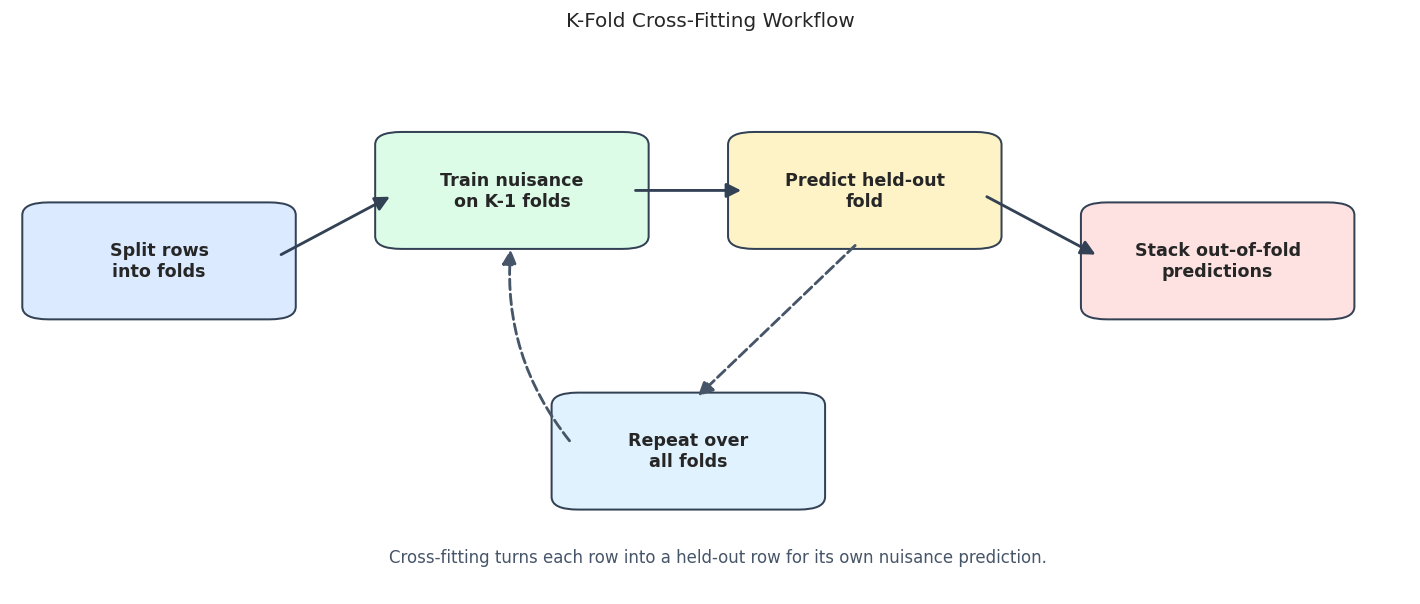

In [6]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

nodes = {
    "split": {"xy": (0.10, 0.62), "label": "Split rows\ninto folds", "color": "#dbeafe"},
    "train": {"xy": (0.34, 0.72), "label": "Train nuisance\non K-1 folds", "color": "#dcfce7"},
    "predict": {"xy": (0.58, 0.72), "label": "Predict held-out\nfold", "color": "#fef3c7"},
    "stack": {"xy": (0.82, 0.62), "label": "Stack out-of-fold\npredictions", "color": "#fee2e2"},
    "repeat": {"xy": (0.46, 0.35), "label": "Repeat over\nall folds", "color": "#e0f2fe"},
}

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.set_axis_off()
ax.set_xlim(0.0, 0.95)
ax.set_ylim(0.15, 0.92)
box_w, box_h = 0.15, 0.13


def box_anchor(name, side):
    x, y = nodes[name]["xy"]
    offsets = {"left": (-box_w / 2, 0), "right": (box_w / 2, 0), "top": (0, box_h / 2), "bottom": (0, -box_h / 2)}
    dx, dy = offsets[side]
    return (x + dx, y + dy)


def draw_arrow(start, end, color="#334155", style="solid", rad=0.0):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=1.7,
        color=color,
        linestyle=style,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=8,
        shrinkB=8,
        zorder=5,
    )
    ax.add_patch(arrow)

for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=10.5, fontweight="bold", zorder=4)

draw_arrow(box_anchor("split", "right"), box_anchor("train", "left"))
draw_arrow(box_anchor("train", "right"), box_anchor("predict", "left"))
draw_arrow(box_anchor("predict", "right"), box_anchor("stack", "left"))
draw_arrow(box_anchor("predict", "bottom"), box_anchor("repeat", "top"), color="#475569", style="dashed", rad=0.0)
draw_arrow(box_anchor("repeat", "left"), box_anchor("train", "bottom"), color="#475569", style="dashed", rad=-0.22)

ax.text(
    0.48,
    0.20,
    "Cross-fitting turns each row into a held-out row for its own nuisance prediction.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("K-Fold Cross-Fitting Workflow", pad=14)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_cross_fitting_workflow.png", bbox_inches="tight")
plt.show()

The workflow is simple but powerful. We are not just validating a predictive model; we are constructing the nuisance predictions that enter the final causal score.

## Visualizing Fold Assignments

This cell creates a 5-fold split and displays the fold assignment for the first rows. The heatmap is a compact way to see that every row belongs to exactly one held-out fold in each repetition.

,rep,fold,heldout_rows
0,1,1,192
1,1,2,192
2,1,3,192
3,1,4,192
4,1,5,192


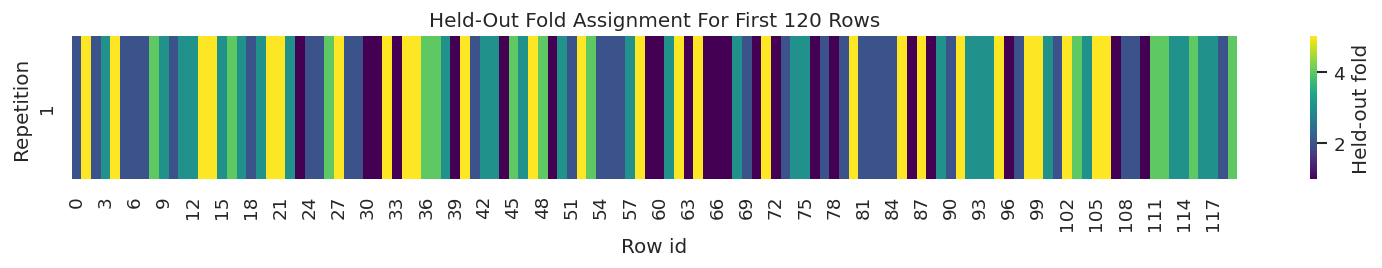

In [7]:
base_splits = make_kfold_splits(plr_df, n_folds=5, seed=RANDOM_SEED)
fold_assignments = fold_assignment_frame([base_splits], n_obs=len(plr_df), n_rep_to_show=1)
fold_preview = fold_assignments.query("row_id < 120").pivot(index="rep", columns="row_id", values="fold")

fold_size_table = (
    fold_assignments.groupby(["rep", "fold"])
    .size()
    .reset_index(name="heldout_rows")
)

save_table(fold_assignments, f"{NOTEBOOK_PREFIX}_fold_assignments.csv")
save_table(fold_size_table, f"{NOTEBOOK_PREFIX}_fold_size_table.csv")

display(fold_size_table)

fig, ax = plt.subplots(figsize=(13, 2.4))
sns.heatmap(fold_preview, cmap="viridis", cbar_kws={"label": "Held-out fold"}, ax=ax)
ax.set_title("Held-Out Fold Assignment For First 120 Rows")
ax.set_xlabel("Row id")
ax.set_ylabel("Repetition")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_fold_assignment_heatmap.png", bbox_inches="tight")
plt.show()

The fold sizes are balanced, and the heatmap shows one held-out fold label per row. DoubleML uses this structure to fit nuisance models and assemble out-of-fold predictions.

## Choosing The Number Of Folds

The number of folds controls a trade-off. More folds mean each nuisance model trains on more rows, but there are more nuisance fits. Fewer folds run faster, but each nuisance model trains on less data.

This section compares 2, 3, 5, and 8 folds using the same learner family. The goal is to understand sensitivity, not to find a universally best fold count.

In [8]:
base_learner = HistGradientBoostingRegressor(
    max_iter=80,
    max_leaf_nodes=13,
    min_samples_leaf=20,
    learning_rate=0.06,
    random_state=RANDOM_SEED,
)

fold_rows = []
fold_models = {}
for n_folds in [2, 3, 5, 8]:
    splits = make_kfold_splits(plr_df, n_folds=n_folds, seed=RANDOM_SEED)
    model, row = fit_plr_with_splits(
        plr_df,
        learner=base_learner,
        label=f"{n_folds}-fold cross-fitting",
        n_folds=n_folds,
        n_rep=1,
        all_smpls=splits,
    )
    fold_models[n_folds] = model
    fold_rows.append(row)

fold_comparison = pd.DataFrame(fold_rows)
save_table(fold_comparison, f"{NOTEBOOK_PREFIX}_fold_count_comparison.csv")
display(fold_comparison)

,label,n_folds,n_rep,theta_hat,se,ci_95_lower,ci_95_upper,bias_vs_true,abs_bias_vs_true,rmse_ml_l,rmse_ml_m,mae_ml_l,mae_ml_m,runtime_seconds
0,2-fold cross-fitting,2,1,0.954285,0.031404,0.892734,1.015836,-0.045715,0.045715,1.594533,1.156154,1.265187,0.924849,0.584970
1,3-fold cross-fitting,3,1,0.959661,0.031427,0.898066,1.021257,-0.040339,0.040339,1.580797,1.137801,1.278498,0.909595,0.802480
2,5-fold cross-fitting,5,1,0.978898,0.031306,0.917539,1.040257,-0.021102,0.021102,1.563875,1.108685,1.242786,0.888654,1.295016
3,8-fold cross-fitting,8,1,0.971195,0.032106,0.908268,1.034121,-0.028805,0.028805,1.562304,1.097198,1.244168,0.873190,2.062652


The estimates move modestly across fold counts. That movement is part of split sensitivity. In real work, large swings across reasonable fold counts would be a reason to slow down and inspect nuisance quality, overlap, and sample size.

## Fold Count Plot

The next plot shows point estimates, confidence intervals, and nuisance RMSE side by side. This keeps the fold-count choice tied to both causal uncertainty and nuisance prediction quality.

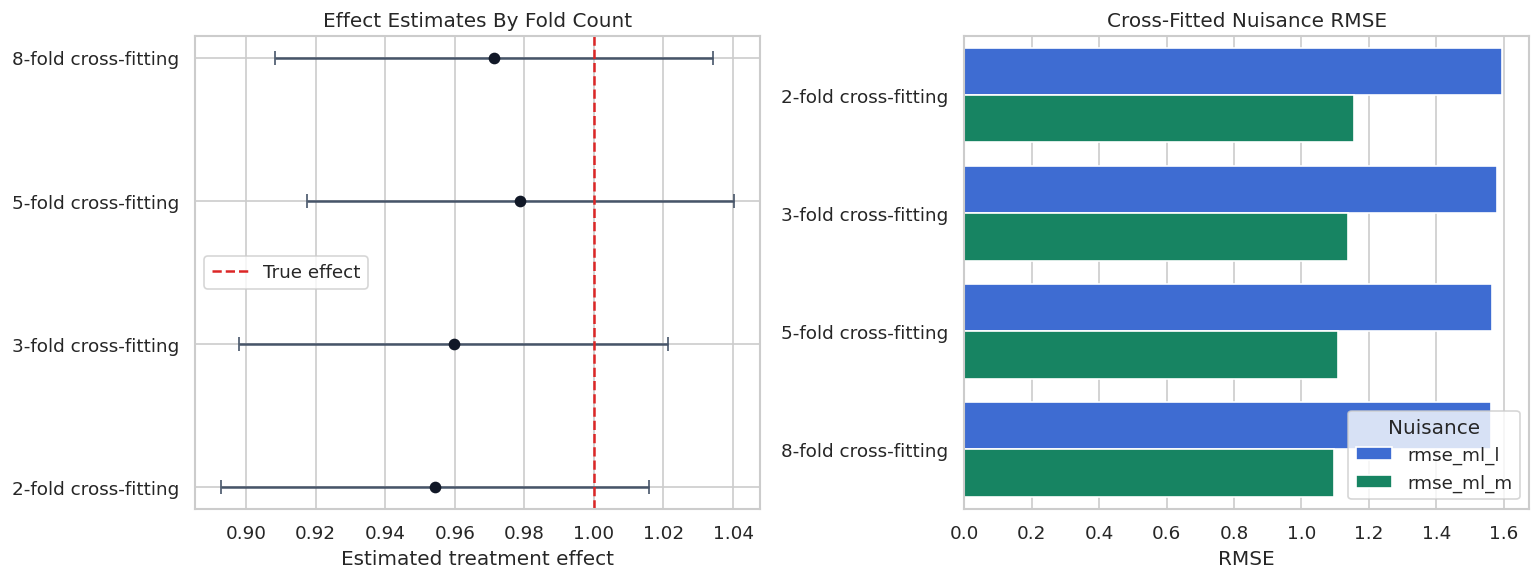

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(
    x=fold_comparison["theta_hat"],
    y=fold_comparison["label"],
    xerr=1.96 * fold_comparison["se"],
    fmt="o",
    color="#111827",
    ecolor="#475569",
    capsize=4,
)
axes[0].axvline(TRUE_THETA, color="#dc2626", linestyle="--", linewidth=1.5, label="True effect")
axes[0].set_title("Effect Estimates By Fold Count")
axes[0].set_xlabel("Estimated treatment effect")
axes[0].set_ylabel("")
axes[0].legend(loc="best")

rmse_plot = fold_comparison.melt(
    id_vars="label",
    value_vars=["rmse_ml_l", "rmse_ml_m"],
    var_name="nuisance",
    value_name="rmse",
)
sns.barplot(data=rmse_plot, x="rmse", y="label", hue="nuisance", palette=["#2563eb", "#059669"], ax=axes[1])
axes[1].set_title("Cross-Fitted Nuisance RMSE")
axes[1].set_xlabel("RMSE")
axes[1].set_ylabel("")
axes[1].legend(title="Nuisance")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_fold_count_comparison.png", bbox_inches="tight")
plt.show()

The RMSE panel shows that nuisance quality changes with fold count, but not always monotonically. Fold choice is a practical design choice, so reporting it is part of reproducibility.

## Repeated Cross-Fitting

Repeated cross-fitting draws multiple K-fold partitions and aggregates the resulting estimates. This helps because a single random partition can be lucky or unlucky, especially in smaller samples or when learners are unstable.

DoubleML stores the per-repetition estimates in `all_coef` and `all_se`. The aggregate estimate is available as `coef` and `se`.

In [10]:
repetition_rows = []
repetition_detail_rows = []
repetition_models = {}

for n_rep in [1, 3, 8]:
    model, row = fit_plr_with_splits(
        plr_df,
        learner=base_learner,
        label=f"5-fold x {n_rep} repetition(s)",
        n_folds=5,
        n_rep=n_rep,
        all_smpls=None,
        seed=RANDOM_SEED,
    )
    repetition_models[n_rep] = model
    repetition_rows.append(row)

    for rep_id, (coef, se) in enumerate(zip(model.all_coef[0], model.all_se[0]), start=1):
        repetition_detail_rows.append(
            {
                "n_rep_setting": n_rep,
                "rep_id": rep_id,
                "theta_hat_rep": float(coef),
                "se_rep": float(se),
                "bias_vs_true": float(coef - TRUE_THETA),
            }
        )

repetition_summary = pd.DataFrame(repetition_rows)
repetition_detail = pd.DataFrame(repetition_detail_rows)

save_table(repetition_summary, f"{NOTEBOOK_PREFIX}_repeated_cross_fitting_summary.csv")
save_table(repetition_detail, f"{NOTEBOOK_PREFIX}_repeated_cross_fitting_detail.csv")

display(repetition_summary)
display(repetition_detail.head(12))

,label,n_folds,n_rep,theta_hat,se,ci_95_lower,ci_95_upper,bias_vs_true,abs_bias_vs_true,rmse_ml_l,rmse_ml_m,mae_ml_l,mae_ml_m,runtime_seconds
0,5-fold x 1 repetition(s),5,1,0.969909,0.033374,0.904497,1.035320,-0.030091,0.030091,1.550840,1.091125,1.231454,0.871381,1.350095
1,5-fold x 3 repetition(s),5,3,0.979004,0.032393,0.915515,1.042493,-0.020996,0.020996,1.568709,1.100427,1.253790,0.878583,3.916755
2,5-fold x 8 repetition(s),5,8,0.985386,0.033241,0.920234,1.050537,-0.014614,0.014614,1.553655,1.106436,1.235832,0.882917,10.016515


,n_rep_setting,rep_id,theta_hat_rep,se_rep,bias_vs_true
0,1,1,0.969909,0.033374,-0.030091
1,3,1,0.986414,0.031716,-0.013586
2,3,2,0.979004,0.032393,-0.020996
3,3,3,0.971292,0.032852,-0.028708
4,8,1,0.964888,0.032001,-0.035112
5,8,2,0.951620,0.033304,-0.048380
6,8,3,0.990378,0.032799,-0.009622
7,8,4,0.998954,0.032592,-0.001046
8,8,5,0.973248,0.032470,-0.026752
9,8,6,1.028002,0.032958,0.028002


The detail table shows the estimates from individual repetitions. The aggregate row becomes less dependent on one particular split as the number of repetitions grows.

## Repeated Split Distribution

A plot makes repeated cross-fitting easier to understand. Each point below is one repetition-specific estimate; the dashed vertical line is the known true effect.

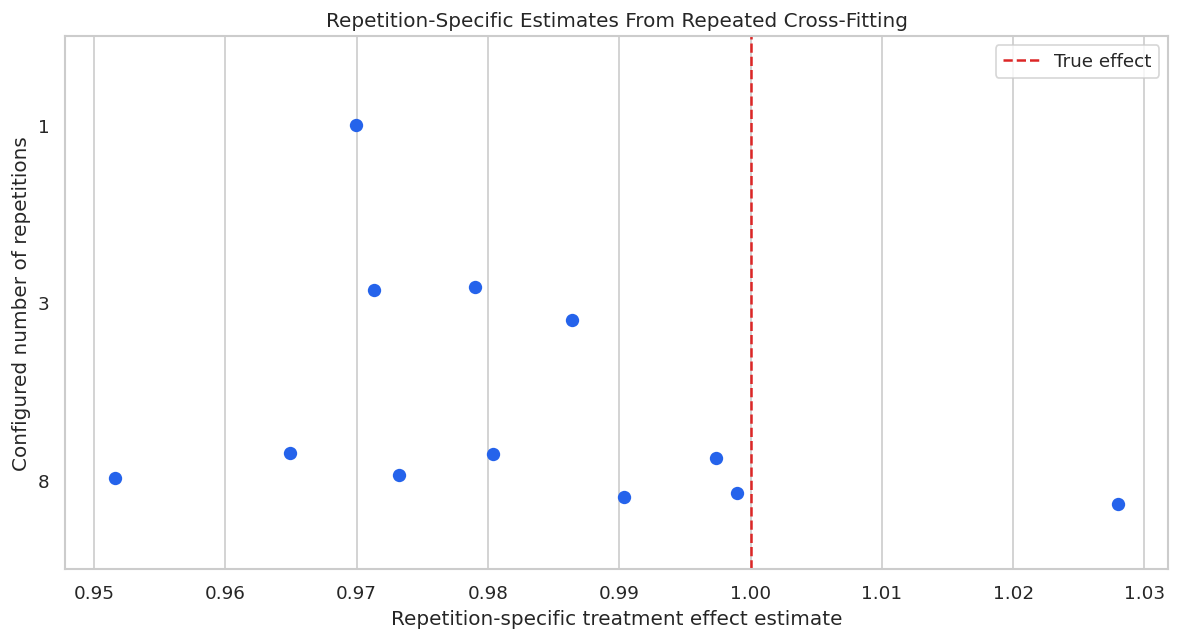

In [11]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.stripplot(
    data=repetition_detail,
    x="theta_hat_rep",
    y="n_rep_setting",
    orient="h",
    size=8,
    jitter=0.16,
    color="#2563eb",
    ax=ax,
)
ax.axvline(TRUE_THETA, color="#dc2626", linestyle="--", linewidth=1.5, label="True effect")
ax.set_title("Repetition-Specific Estimates From Repeated Cross-Fitting")
ax.set_xlabel("Repetition-specific treatment effect estimate")
ax.set_ylabel("Configured number of repetitions")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_repeated_cross_fitting_distribution.png", bbox_inches="tight")
plt.show()

The individual points vary because each repetition uses a different random partition. Repeated cross-fitting is useful when that variation is nontrivial and the extra runtime is acceptable.

## External Sample Splits

Sometimes random K-fold splitting is not the right design. If observations are grouped by user, household, region, device, school, or time period, the held-out fold may need to respect that structure.

This section compares ordinary random K-fold splits with `GroupKFold` splits by `user_id`. The model controls still exclude `user_id`; the group is used only to define fold boundaries.

In [12]:
random_group_audit = group_overlap_audit(plr_df, base_splits, group_col="user_id")
group_splits = list(GroupKFold(n_splits=5).split(plr_df, groups=plr_df["user_id"]))
group_split_audit = group_overlap_audit(plr_df, group_splits, group_col="user_id")

random_group_audit["split_type"] = "Random KFold"
group_split_audit["split_type"] = "GroupKFold by user_id"
split_group_audit = pd.concat([random_group_audit, group_split_audit], ignore_index=True)

save_table(split_group_audit, f"{NOTEBOOK_PREFIX}_external_split_group_audit.csv")
display(split_group_audit)

,fold,train_rows,test_rows,train_groups,test_groups,overlap_groups,split_type
0,1,768,192,239,150,149,Random KFold
1,2,768,192,240,143,143,Random KFold
2,3,768,192,238,141,139,Random KFold
3,4,768,192,238,138,136,Random KFold
4,5,768,192,237,133,130,Random KFold
5,1,768,192,192,48,0,GroupKFold by user_id
6,2,768,192,192,48,0,GroupKFold by user_id
7,3,768,192,192,48,0,GroupKFold by user_id
8,4,768,192,192,48,0,GroupKFold by user_id
9,5,768,192,192,48,0,GroupKFold by user_id


Random K-fold splits can place the same user in both training and held-out folds. GroupKFold prevents group overlap, which is often the right validation logic when rows from the same group are closely related.

## Random Versus Group-Aware Splits

Now we fit DoubleML with random K-fold splits and with external GroupKFold splits. The comparison shows how to pass a custom split list into DoubleML with `set_sample_splitting()`.

In [13]:
random_split_model, random_split_row = fit_plr_with_splits(
    plr_df,
    learner=base_learner,
    label="External random KFold",
    n_folds=5,
    n_rep=1,
    all_smpls=base_splits,
)

group_split_model, group_split_row = fit_plr_with_splits(
    plr_df,
    learner=base_learner,
    label="External GroupKFold by user_id",
    n_folds=5,
    n_rep=1,
    all_smpls=group_splits,
)

external_split_comparison = pd.DataFrame([random_split_row, group_split_row])
save_table(external_split_comparison, f"{NOTEBOOK_PREFIX}_external_split_comparison.csv")
display(external_split_comparison)

,label,n_folds,n_rep,theta_hat,se,ci_95_lower,ci_95_upper,bias_vs_true,abs_bias_vs_true,rmse_ml_l,rmse_ml_m,mae_ml_l,mae_ml_m,runtime_seconds
0,External random KFold,5,1,0.978898,0.031306,0.917539,1.040257,-0.021102,0.021102,1.563875,1.108685,1.242786,0.888654,1.342976
1,External GroupKFold by user_id,5,1,0.986529,0.031902,0.924002,1.049056,-0.013471,0.013471,1.583457,1.121916,1.258856,0.894433,1.230137


The group-aware estimate is similar in this synthetic data, but the split audit still matters. In real grouped data, preventing group leakage can be more important than a small change in point estimates.

## Group Overlap Plot

This plot visualizes the split audit. The goal of GroupKFold is not to change the estimate mechanically; the goal is to enforce a design rule that no user appears in both training and held-out rows for a fold.

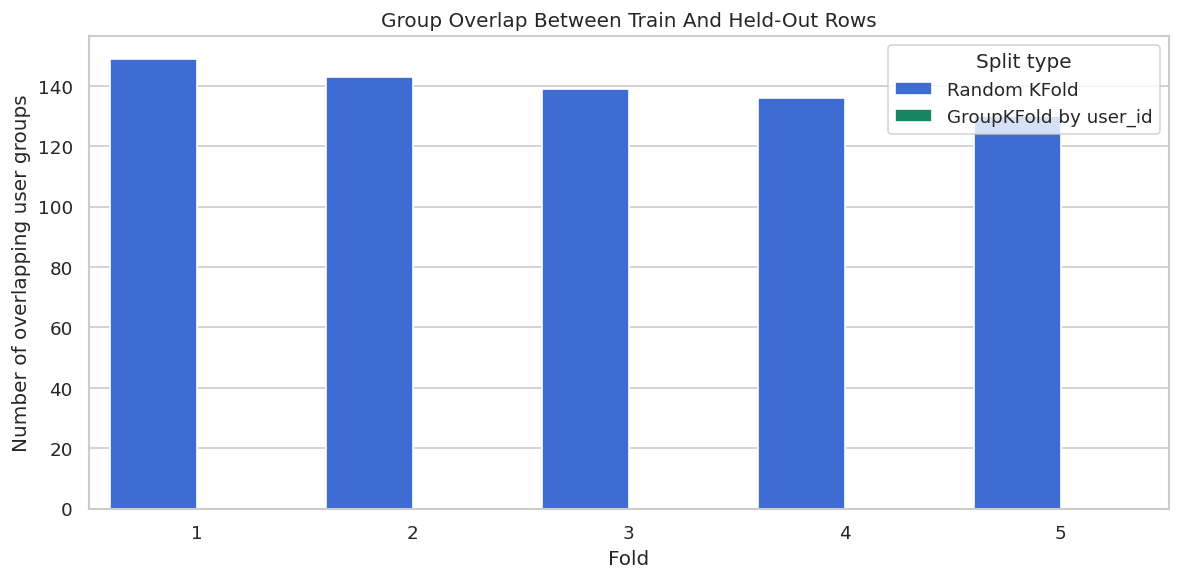

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=split_group_audit, x="fold", y="overlap_groups", hue="split_type", ax=ax, palette=["#2563eb", "#059669"])
ax.set_title("Group Overlap Between Train And Held-Out Rows")
ax.set_xlabel("Fold")
ax.set_ylabel("Number of overlapping user groups")
ax.legend(title="Split type")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_group_overlap_audit.png", bbox_inches="tight")
plt.show()

The GroupKFold bars are zero because each user is held out as a whole unit. That is the central reason to use external splits: they let the analyst encode validation constraints that the default random splitter cannot know.

## Manual No-Cross-Fitting Caution

DoubleML is designed around out-of-fold nuisance predictions. To see why, we now construct a manual cautionary example with an extremely flexible `ExtraTreesRegressor`.

The in-sample version fits nuisance models on all rows and predicts those same rows. The cross-fitted version trains on K-1 folds and predicts the held-out fold. Both then run the same residual-on-residual regression.

This is not meant to replace DoubleML's implementation. It is a visual caution about why in-sample residualization is dangerous.

In [15]:
overfit_learner = ExtraTreesRegressor(
    n_estimators=200,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=RANDOM_SEED,
    n_jobs=1,
)

no_cross_df = plr_df.sample(n=600, random_state=RANDOM_SEED).reset_index(drop=True)
no_cross_x_cols = model_x_cols(no_cross_df)

# In-sample residualization: fit and predict on the same rows.
insample_l = clone(overfit_learner).fit(no_cross_df[no_cross_x_cols], no_cross_df["outcome"])
insample_m = clone(overfit_learner).fit(no_cross_df[no_cross_x_cols], no_cross_df["treatment"])
insample_y_hat = insample_l.predict(no_cross_df[no_cross_x_cols])
insample_d_hat = insample_m.predict(no_cross_df[no_cross_x_cols])
insample_y_res = no_cross_df["outcome"].to_numpy() - insample_y_hat
insample_d_res = no_cross_df["treatment"].to_numpy() - insample_d_hat
insample_theta = LinearRegression(fit_intercept=False).fit(insample_d_res.reshape(-1, 1), insample_y_res).coef_[0]

# Manual cross-fitting: held-out predictions for every row.
cf_y_hat = np.zeros(len(no_cross_df))
cf_d_hat = np.zeros(len(no_cross_df))
manual_splits = make_kfold_splits(no_cross_df, n_folds=5, seed=RANDOM_SEED)
for train_idx, test_idx in manual_splits:
    fold_l = clone(overfit_learner).fit(no_cross_df.iloc[train_idx][no_cross_x_cols], no_cross_df.iloc[train_idx]["outcome"])
    fold_m = clone(overfit_learner).fit(no_cross_df.iloc[train_idx][no_cross_x_cols], no_cross_df.iloc[train_idx]["treatment"])
    cf_y_hat[test_idx] = fold_l.predict(no_cross_df.iloc[test_idx][no_cross_x_cols])
    cf_d_hat[test_idx] = fold_m.predict(no_cross_df.iloc[test_idx][no_cross_x_cols])

cf_y_res = no_cross_df["outcome"].to_numpy() - cf_y_hat
cf_d_res = no_cross_df["treatment"].to_numpy() - cf_d_hat
cf_theta = LinearRegression(fit_intercept=False).fit(cf_d_res.reshape(-1, 1), cf_y_res).coef_[0]

manual_crossfit_comparison = pd.DataFrame(
    [
        {
            "method": "In-sample nuisance residualization",
            "theta_hat": insample_theta,
            "bias_vs_true": insample_theta - TRUE_THETA,
            "outcome_nuisance_rmse": mean_squared_error(no_cross_df["outcome"], insample_y_hat) ** 0.5,
            "treatment_nuisance_rmse": mean_squared_error(no_cross_df["treatment"], insample_d_hat) ** 0.5,
            "treatment_residual_sd": np.std(insample_d_res),
        },
        {
            "method": "Manual 5-fold cross-fitting",
            "theta_hat": cf_theta,
            "bias_vs_true": cf_theta - TRUE_THETA,
            "outcome_nuisance_rmse": mean_squared_error(no_cross_df["outcome"], cf_y_hat) ** 0.5,
            "treatment_nuisance_rmse": mean_squared_error(no_cross_df["treatment"], cf_d_hat) ** 0.5,
            "treatment_residual_sd": np.std(cf_d_res),
        },
    ]
)

save_table(manual_crossfit_comparison, f"{NOTEBOOK_PREFIX}_manual_no_cross_fit_caution.csv")
display(manual_crossfit_comparison)

,method,theta_hat,bias_vs_true,outcome_nuisance_rmse,treatment_nuisance_rmse,treatment_residual_sd
0,In-sample nuisance residualization,-0.049285,-1.049285,5.766047e-15,3.803450e-15,3.802177e-15
1,Manual 5-fold cross-fitting,1.000418,0.000418,1.627348e+00,1.114617e+00,1.114522e+00


The in-sample nuisance RMSE is almost zero because the flexible trees can interpolate the training rows. That looks excellent as prediction output, but it destroys the residual structure needed for causal estimation. The cross-fitted residuals are noisier in a healthy way: they are honest held-out residuals.

## No-Cross-Fitting Caution Plot

The plot below puts the cautionary comparison on two panels: effect estimate and treatment-residual standard deviation. The in-sample residual standard deviation can become tiny when the learner memorizes the training data.

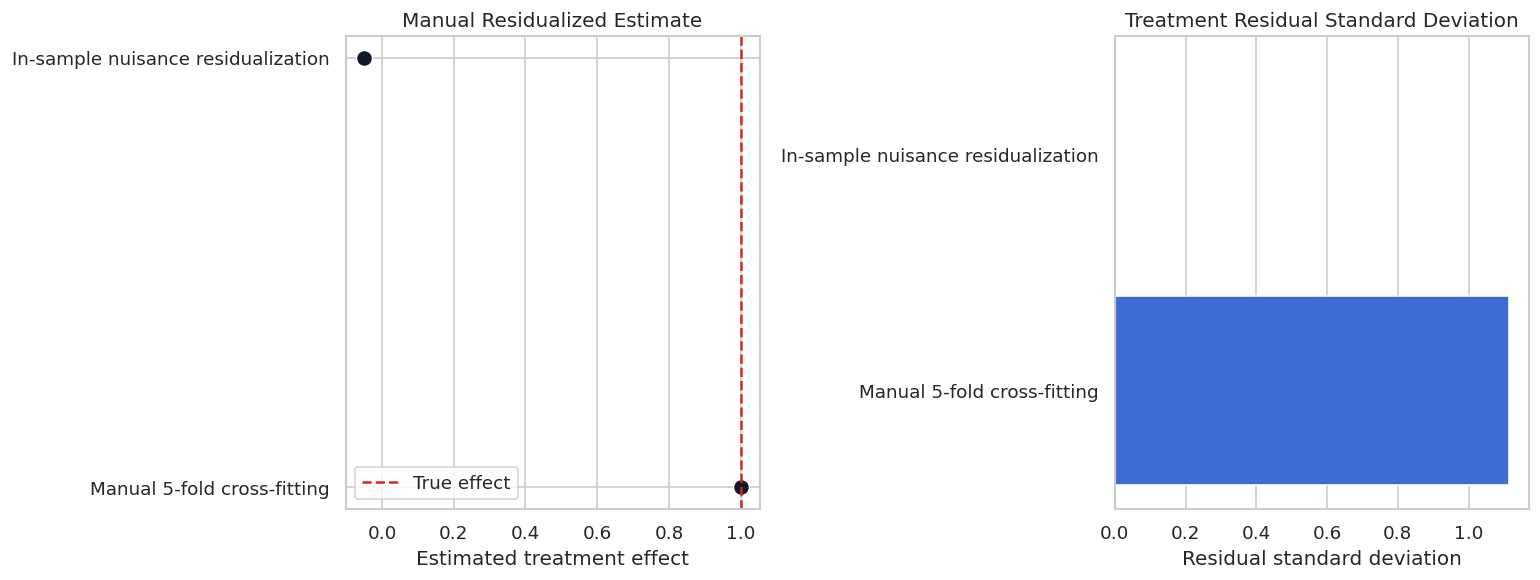

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=manual_crossfit_comparison,
    x="theta_hat",
    y="method",
    s=90,
    color="#111827",
    ax=axes[0],
)
axes[0].axvline(TRUE_THETA, color="#dc2626", linestyle="--", linewidth=1.5, label="True effect")
axes[0].set_title("Manual Residualized Estimate")
axes[0].set_xlabel("Estimated treatment effect")
axes[0].set_ylabel("")
axes[0].legend(loc="best")

sns.barplot(data=manual_crossfit_comparison, x="treatment_residual_sd", y="method", color="#2563eb", ax=axes[1])
axes[1].set_title("Treatment Residual Standard Deviation")
axes[1].set_xlabel("Residual standard deviation")
axes[1].set_ylabel("")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_manual_no_cross_fit_caution.png", bbox_inches="tight")
plt.show()

This is the clearest practical reason for cross-fitting: training-set predictions can be too good to be useful. The causal score needs held-out nuisance predictions, not memorized training residuals.

## Split Reporting Checklist

A reproducible DoubleML analysis should document its split design. This checklist can be copied into applied notebooks and reports.

In [17]:
split_reporting_checklist = pd.DataFrame(
    [
        {"item": "State number of folds", "why": "Fold count changes training size and number of nuisance fits."},
        {"item": "State number of repetitions", "why": "Repeated cross-fitting affects split stability and runtime."},
        {"item": "Record random seeds", "why": "Random sample splits should be reproducible."},
        {"item": "Explain external split constraints", "why": "Grouped, clustered, or temporal data often require custom split logic."},
        {"item": "Report nuisance prediction diagnostics", "why": "Split design should be assessed with held-out nuisance performance."},
        {"item": "Show split sensitivity when material", "why": "Large changes across reasonable splits weaken confidence in one estimate."},
        {"item": "Avoid in-sample nuisance residualization", "why": "Flexible learners can memorize rows and distort the orthogonal score."},
    ]
)

save_table(split_reporting_checklist, f"{NOTEBOOK_PREFIX}_split_reporting_checklist.csv")
display(split_reporting_checklist)

,item,why
0,State number of folds,Fold count changes training size and number of...
1,State number of repetitions,Repeated cross-fitting affects split stability...
2,Record random seeds,Random sample splits should be reproducible.
3,Explain external split constraints,"Grouped, clustered, or temporal data often req..."
4,Report nuisance prediction diagnostics,Split design should be assessed with held-out ...
5,Show split sensitivity when material,Large changes across reasonable splits weaken ...
6,Avoid in-sample nuisance residualization,Flexible learners can memorize rows and distor...


The checklist makes split design part of the causal audit trail. It also helps separate honest split sensitivity from casual rerunning until a pleasing estimate appears.

## Report Template And Artifact Manifest

The final cell writes a short split-design report template and an artifact manifest. The template is intentionally concise, but it includes the details that should be visible in a serious DoubleML write-up.

In [18]:
report_text = f"""
# Sample Splitting And Cross-Fitting Report Template

## Model
- DoubleML model class:
- Treatment:
- Outcome:
- Control set:
- Primary learner:

## Split Design
- Number of folds:
- Number of repetitions:
- Random seed(s):
- Internal or external splits:
- Group, cluster, or time constraints:

## Diagnostics
- Outcome nuisance RMSE:
- Treatment nuisance RMSE:
- Split sensitivity across fold counts:
- Repetition-specific estimate range:
- Group overlap audit, if applicable:

## Final Estimate
- Point estimate:
- Standard error:
- Confidence interval:
- Split-related caveats:
""".strip()

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_sample_splitting_report_template.md"
report_path.write_text(report_text)

artifact_manifest = pd.DataFrame(
    [
        {"artifact": "synthetic PLR data", "path": str(DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_panel_like_plr_data.csv")},
        {"artifact": "fold count comparison", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fold_count_comparison.csv")},
        {"artifact": "repeated cross-fitting summary", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_repeated_cross_fitting_summary.csv")},
        {"artifact": "external split audit", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_external_split_group_audit.csv")},
        {"artifact": "manual no-cross-fit caution", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_manual_no_cross_fit_caution.csv")},
        {"artifact": "report template", "path": str(report_path)},
        {"artifact": "cross-fitting workflow figure", "path": str(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_cross_fitting_workflow.png")},
        {"artifact": "fold assignment heatmap", "path": str(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_fold_assignment_heatmap.png")},
    ]
)

save_table(artifact_manifest, f"{NOTEBOOK_PREFIX}_artifact_manifest.csv")
display(Markdown(f"Report template written to `{report_path}`"))
display(artifact_manifest)

Report template written to `/home/apex/Documents/ranking_sys/notebooks/tutorials/doubleml/outputs/reports/11_sample_splitting_report_template.md`

,artifact,path
0,synthetic PLR data,/home/apex/Documents/ranking_sys/notebooks/tut...
1,fold count comparison,/home/apex/Documents/ranking_sys/notebooks/tut...
2,repeated cross-fitting summary,/home/apex/Documents/ranking_sys/notebooks/tut...
3,external split audit,/home/apex/Documents/ranking_sys/notebooks/tut...
4,manual no-cross-fit caution,/home/apex/Documents/ranking_sys/notebooks/tut...
5,report template,/home/apex/Documents/ranking_sys/notebooks/tut...
6,cross-fitting workflow figure,/home/apex/Documents/ranking_sys/notebooks/tut...
7,fold assignment heatmap,/home/apex/Documents/ranking_sys/notebooks/tut...


The notebook now has a full split-design workflow: theory, API mechanics, fold-count sensitivity, repeated cross-fitting, external group splits, and a concrete warning against in-sample residualization.

## What Comes Next

The next natural topic is inference: standard errors, confidence intervals, bootstrap options, joint inference, and how to communicate uncertainty from DoubleML estimates.